In [38]:
from langchain_community.document_loaders import TextLoader, DirectoryLoader
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.output_parsers import StrOutputParser
from pathlib import Path
from dotenv import load_dotenv

In [39]:
load_dotenv()

True

In [40]:
llm = ChatOpenAI(model = "gpt-4o-mini")
embedder = OpenAIEmbeddings(model = "text-embedding-3-small", dimensions=1024)

In [41]:
loader = DirectoryLoader(path=Path("../data/processed").as_posix(),
                         loader_cls=TextLoader,
                         show_progress=True)

docs = loader.load()


100%|██████████| 14/14 [00:01<00:00,  8.25it/s]


In [42]:
docs[2].page_content[:1000]

"Hi guys, good evening, how are you all?\nCan you hear me?\nOkay, thank you.\nLet's start the session in a little while.\nBefore that, we have some time, around 5 minutes.\nSo whoever is here, if you have any questions, you can ask.\nOkay, let's start.\nOkay,\nOkay, so you can ask.\nSir,\nI\nknow.\nCan't say right now, honestly, because\nbut yeah, we'll try.\nAt least\nI can conduct a meetup.\nMost likely next month, July, may I'm planning to come there.\nSo we can have a meetup then.\nI'm not from Delhi. Currently, I'm staying in\nGurdwara.\nHow many people have come?\nWe have around 38 people.\nIt's 6 o'clock. Let's wait for 2 more minutes and then start.\nBecause this is the first session, immediately starting at this time.\nIt's possible that some other people join.\nOn\n10th, I guess, on 10th, there was one session where it is.\nSo, AI workplace, which is your actual name,\nthe course through which you have joined,\nyou will be shown in the past sessions orientation session.\nIs t

In [43]:
chunker = RecursiveCharacterTextSplitter(chunk_size = 500,
                                         chunk_overlap = 50)

chunks = chunker.split_documents(docs)

In [44]:
print(f"chunks: {len(chunks)}")

chunks: 2617


In [45]:
vs = Chroma(collection_name='rag_demo',
            embedding_function=embedder,
            persist_directory=Path("../saved-embeddings").as_posix())

vs.add_documents(chunks)

['ad4c9503-ffe7-4c4d-8b79-17dda7dc30c8',
 'eb3bdabb-ecbe-445f-8cee-b4fb82393764',
 '48973b78-1b15-471f-a1e9-cee463e5652f',
 '8a02fe0f-834d-4435-87f1-ea502be34594',
 '89cdb61a-79cb-4cc0-9410-37c91be02922',
 '69e79687-7e1d-4199-83af-826e08039fb2',
 'cfaaa76b-e19b-4b8c-b968-fe48d7b3c6b6',
 '137dcffa-55f9-4264-9a0b-bc7d0a005775',
 'edfe2aa2-3b43-40e7-84d8-40eb2a6954d0',
 '0c6b46ca-e9b2-43c2-9a45-dd7ae186425a',
 '28f5f383-180c-478e-9e36-eafe2a27cc51',
 '34120d52-8e87-4f5c-93e8-c900620e0276',
 '3423fc41-80e7-430c-b64b-49e5e1ba2bf2',
 '3333b946-90da-4201-ac43-822fea33cd11',
 '3636b304-70bf-4ddd-8bd7-ee8923d62b6c',
 'cbcda53b-504a-4faf-85cb-961b53888b39',
 'dd22662b-7e0a-43ab-91a7-7220f7d461a1',
 '6ed18fa2-d14d-4989-be7a-b5695468ad8c',
 '397150d7-b797-45f9-a735-7a4097b93f6c',
 'a412ebf2-0bf2-4ee5-8226-9f1808b82c60',
 '4c7285b0-212e-4197-b8ca-1893e4f396c0',
 '7d8f21ae-903d-4208-b984-cba95259bb52',
 '60ccac0d-bc29-4540-af74-046bc718789b',
 '37aece8d-7105-4cf6-8a39-c6d4a5bbe2ae',
 'a5fc21ae-3b41-

In [64]:
retriever = vs.as_retriever(search_kwargs = {'k':3},search_type = 'similarity')

In [47]:
from langgraph.graph import StateGraph, START, END
from typing import Literal, TypedDict

In [62]:
class RAGState(TypedDict):

    query: str
    retrieved_docs: list[Document]
    context: str
    prompt: ChatPromptTemplate
    response: str

In [65]:
def retrieve(state: RAGState) -> dict:
    query = state["query"]
    retrieved_docs = retriever.invoke(query)

    context = "\n\n".join([doc.page_content for doc in retrieved_docs])
    return {"retrieved_docs": retrieved_docs, "context": context}

In [66]:
def augmentation(state: RAGState) -> dict:

    prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a helpful assistant. Answer the user query
                      based on the given context only. If you do not know the answer
                      say I don't know. Do not add any preamble to the response"""),
        ("human", "context: {context}\n\nquery: {query}")
    ])
    
    return {"prompt": prompt}

In [67]:
def generation(state: RAGState) -> dict:

    query = state['query']
    context = state['context']
    prompt = state['prompt']

    rag_chain = prompt | llm | StrOutputParser()
    response = rag_chain.invoke({'context': context, 'query': query})

    return {"response": response}

In [68]:
graph_builder = StateGraph(RAGState)

graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("augmentation", augmentation)
graph_builder.add_node("generation", generation)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "augmentation")
graph_builder.add_edge("augmentation", "generation")
graph_builder.add_edge("generation", END)

graph = graph_builder.compile()

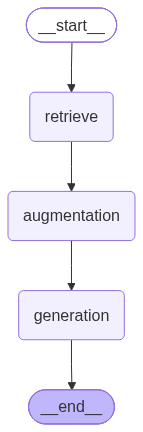

In [69]:
graph

In [70]:
result = graph.invoke({"query": "what is llm evals"})

In [73]:
print(result['response'])

LLM evals is a study of evaluating LLM based applications. It involves systematic and repeatable tests used to measure whether an LLM or an LLM based application is performing well. This includes assessing if the application is doing a good job, if it is ready for launch, and if users can effectively use it.


In [74]:
result['context']

"LLM evals is basically a study of evaluating LLM based applications.\nHow do you know if it is doing a good job, if it is doing a good job, if you can launch it, if users can use it.\nThis is the study of LLM evals.\nAnd this is what we are going to cover in this course.\nNow if you see this course from end to end then you will get two advantages.\nThe first advantage is that you will get some edge over your competition.\nToday's students are mostly studying these topics.\n\nLLM evals is basically a study of evaluating LLM based applications.\nHow do you know if it is doing a good job, if it is doing a good job, if you can launch it, if users can use it.\nThis is the study of LLM evals.\nAnd this is what we are going to cover in this course.\nNow if you see this course from end to end then you will get two advantages.\nThe first advantage is that you will get some edge over your competition.\nToday's students are mostly studying these topics.\n\nOkay.\nSo finally we will\ndiscuss what